# QA Multi-Agent Pipeline Prototype Demonstration
## CM3070 Computer Science Final Project

This notebook demonstrates the feature prototype for an orchestrated 
multi-agent AI system for automated UX and functional testing of web applications.

### Pipeline Architecture
1. Crawl Agent - Playwright navigates the target application and captures screenshots and DOM snapshots
2. Vision Agent - GPT-4o analyses each screenshot and identifies UI/UX and functional defects
3. Report Agent - LLM synthesises findings into a structured incident report
4. HTML Renderer - Generates a self-contained HTML report with embedded screenshots and recommended fixes

### Test Target
- Application: SauceDemo (www.saucedemo.com) - an e-commerce web application intentionally designed with known defects
- Methodology: Two pipeline runs for `standard_user` and `problem_user` (known defects)
- Evaluation: Findings compared against documented ground truth bugs from community QA repositories

In [1]:
#Cell 1: Imports & Setup
import os
import sys
import sqlite3
from pathlib import Path
from IPython.display import display, HTML, IFrame
import nest_asyncio

#Running async Playwright inside Jupyter
nest_asyncio.apply()

#Add project root to path
sys.path.append(str(Path.cwd()))

from db import get_conn, init_db
from orchestrator import run_pipeline

print("Setup complete")

Setup complete


In [2]:
#Cell 2: Run the Pipeline
#Clear any previous run data
if os.path.exists("qa_pipeline.db"):
    os.remove("qa_pipeline.db")
    print("Cleared previous run data")

#Run 1: standard_user, checking baseline functionality
print("\n--- RUN 1: standard_user (baseline) ---")
result_standard = run_pipeline(
    url="https://www.saucedemo.com",
    username="standard_user",
    password="secret_sauce"
)

#Run 2: problem_user with known defects
print("\n--- RUN 2: problem_user (known defects) ---")
result_problem = run_pipeline(
    url="https://www.saucedemo.com",
    username="problem_user",
    password="secret_sauce"
)

print("\nBoth pipeline runs complete.")


--- RUN 1: standard_user (baseline) ---

Pipeline starting
Target: https://www.saucedemo.com
User: standard_user

Database initialised
Run ID: 1

Crawl Agent starting for https://www.saucedemo.com as 'standard_user'...
  Logged in as standard_user
  Captured inventory page
  Captured product page
  Captured cart page
  Captured checkout page
Crawl Agent complete — 4 pages captured
Vision Agent starting analysis...
  Analysing: https://www.saucedemo.com/inventory.html
  Found 3 issue(s)
  Analysing: https://www.saucedemo.com/inventory-item.html?id=4
  Found 3 issue(s)
  Analysing: https://www.saucedemo.com/cart.html
  Found 3 issue(s)
  Analysing: https://www.saucedemo.com/checkout-step-one.html
  Found 4 issue(s)
Vision Agent complete — 13 total findings
Report Agent generating markdown report...
Markdown report saved to /Users/sofiadeich/Documents/Documents - Sofia’s MacBook Pro/FINAL PROJECT/qa-multiagent-pipeline/outputs/report_1_standard_user.md
Generating HTML report...
HTML repo

In [3]:
#Cell 3: Results Summary
standard_findings = result_standard["findings"]
problem_findings = result_problem["findings"]

def count_severity(findings, severity):
    return len([f for f in findings if f["severity"] == severity])

print("PIPELINE RESULTS")
print("="*55)
print(f"{'Metric':<30} {'standard_user':>12} {'problem_user':>12}")
print("-"*55)
print(f"{'Total findings':<30} {len(standard_findings):>12} {len(problem_findings):>12}")
print(f"{'Critical':<30} {count_severity(standard_findings, 'critical'):>12} {count_severity(problem_findings, 'critical'):>12}")
print(f"{'Major':<30} {count_severity(standard_findings, 'major'):>12} {count_severity(problem_findings, 'major'):>12}")
print(f"{'Minor':<30} {count_severity(standard_findings, 'minor'):>12} {count_severity(problem_findings, 'minor'):>12}")
print("="*55)

PIPELINE RESULTS
Metric                         standard_user problem_user
-------------------------------------------------------
Total findings                           13           15
Critical                                  0            0
Major                                     1            4
Minor                                    12           11


standard_user report:


Target Application,https://www.saucedemo.com
User Role Tested,standard_user
Pages Analysed,4
Total Issues,"13 (0 critical, 1 major, 12 minor)"
Run ID,1

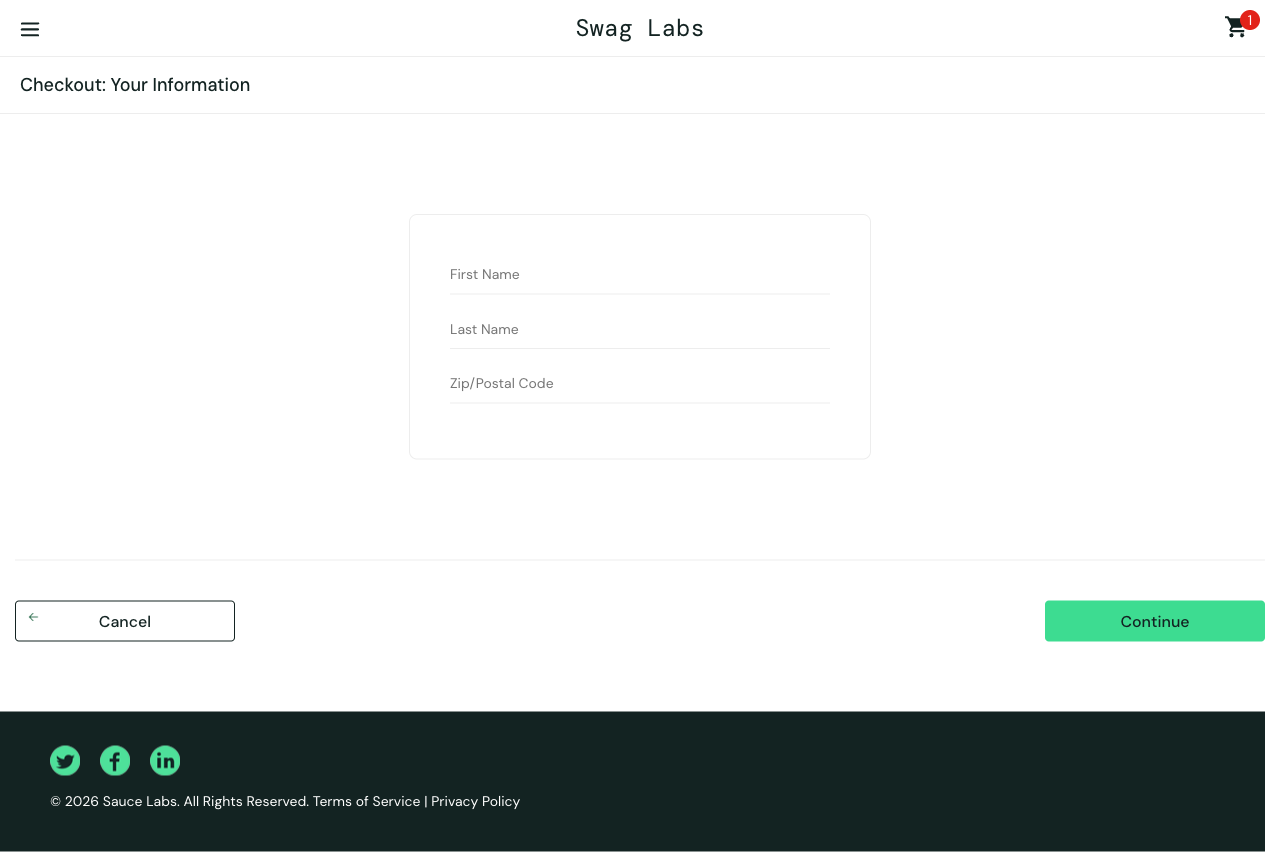
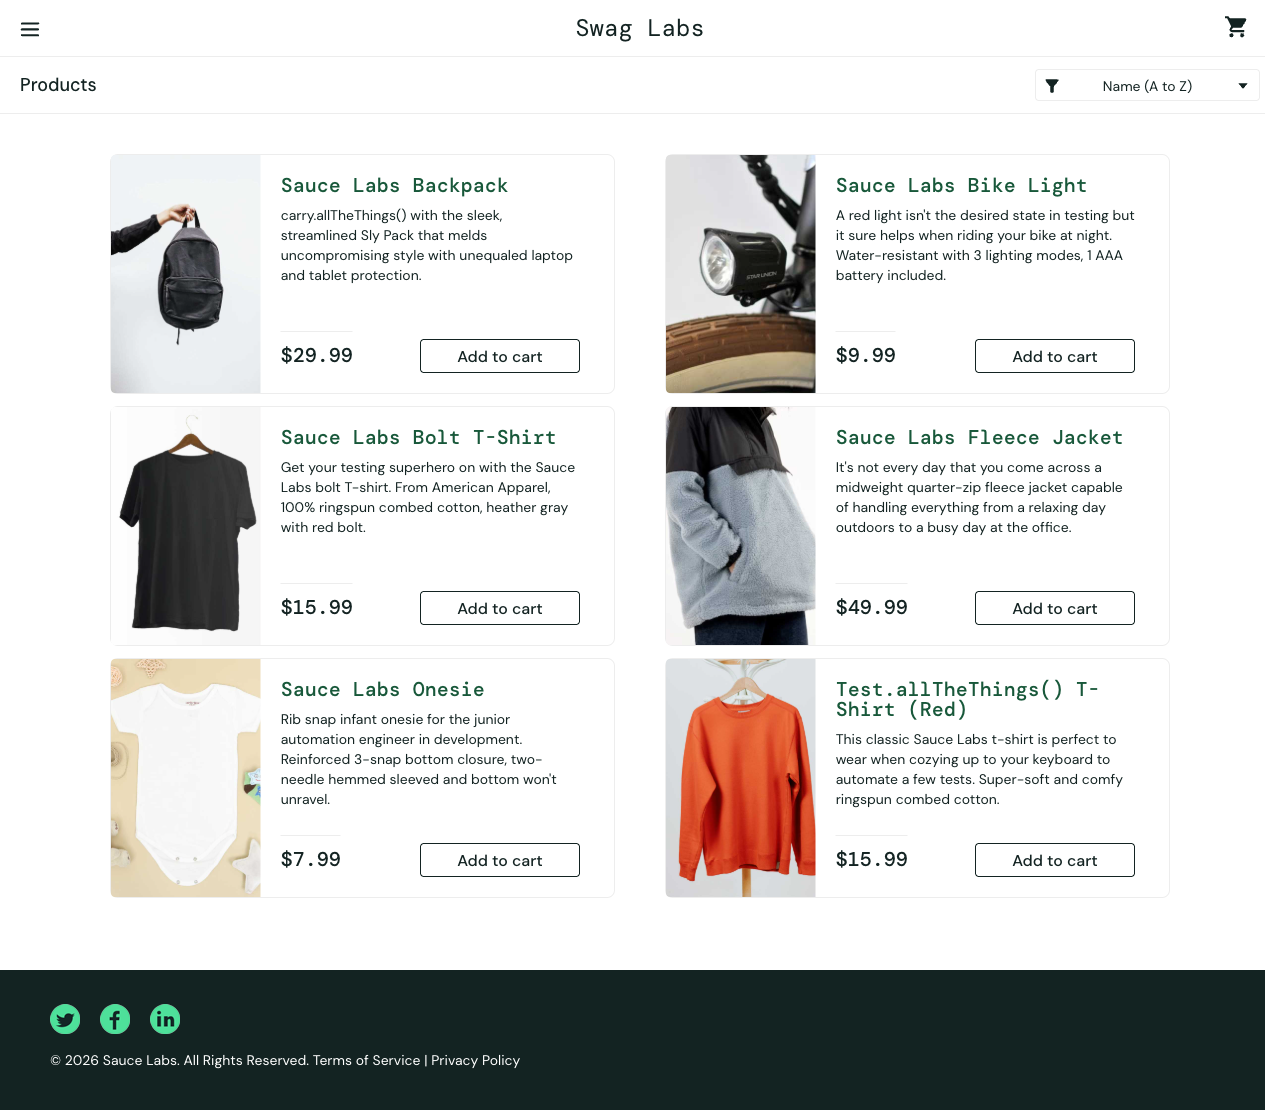
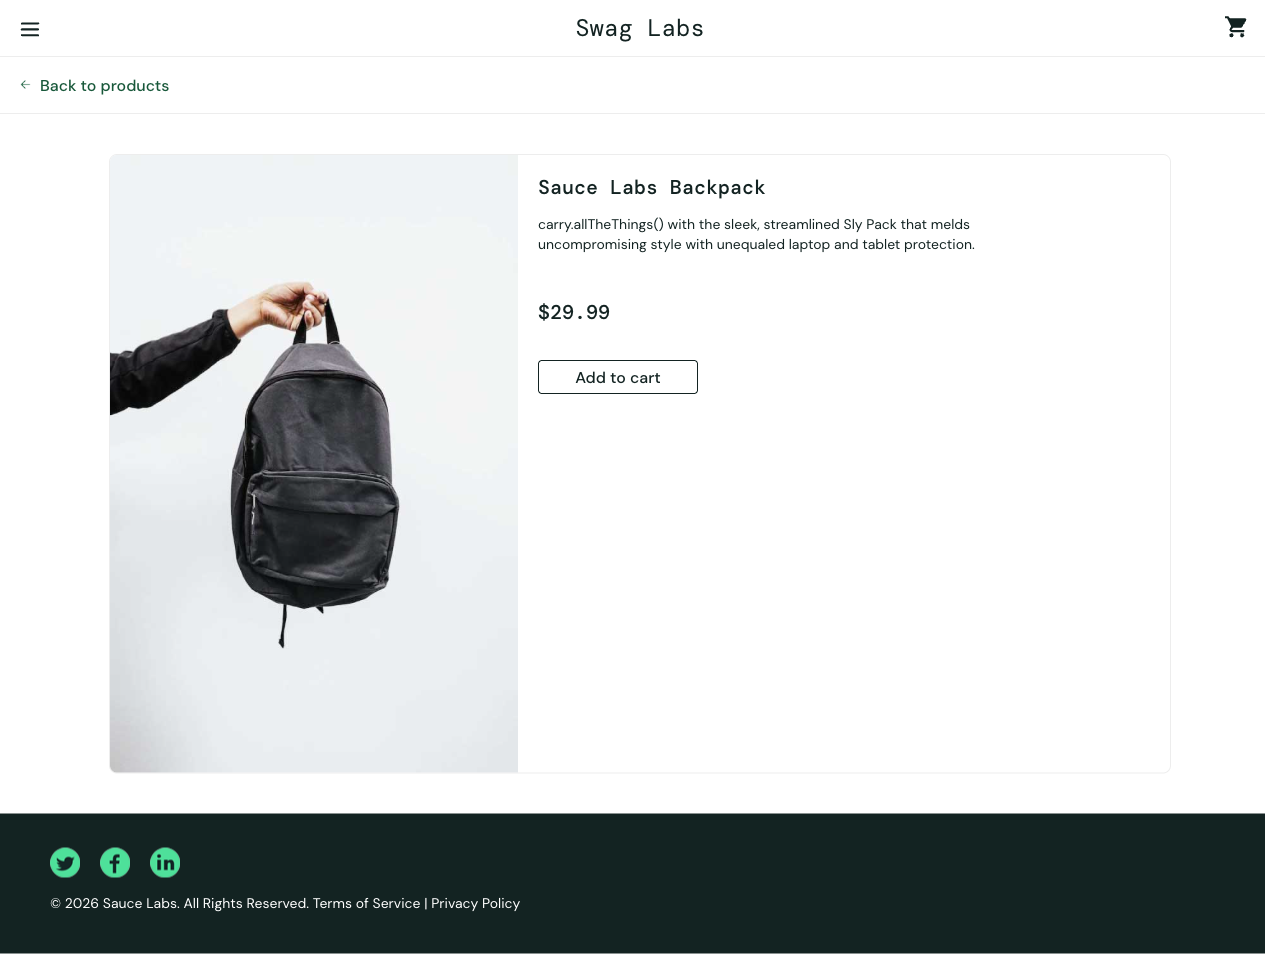
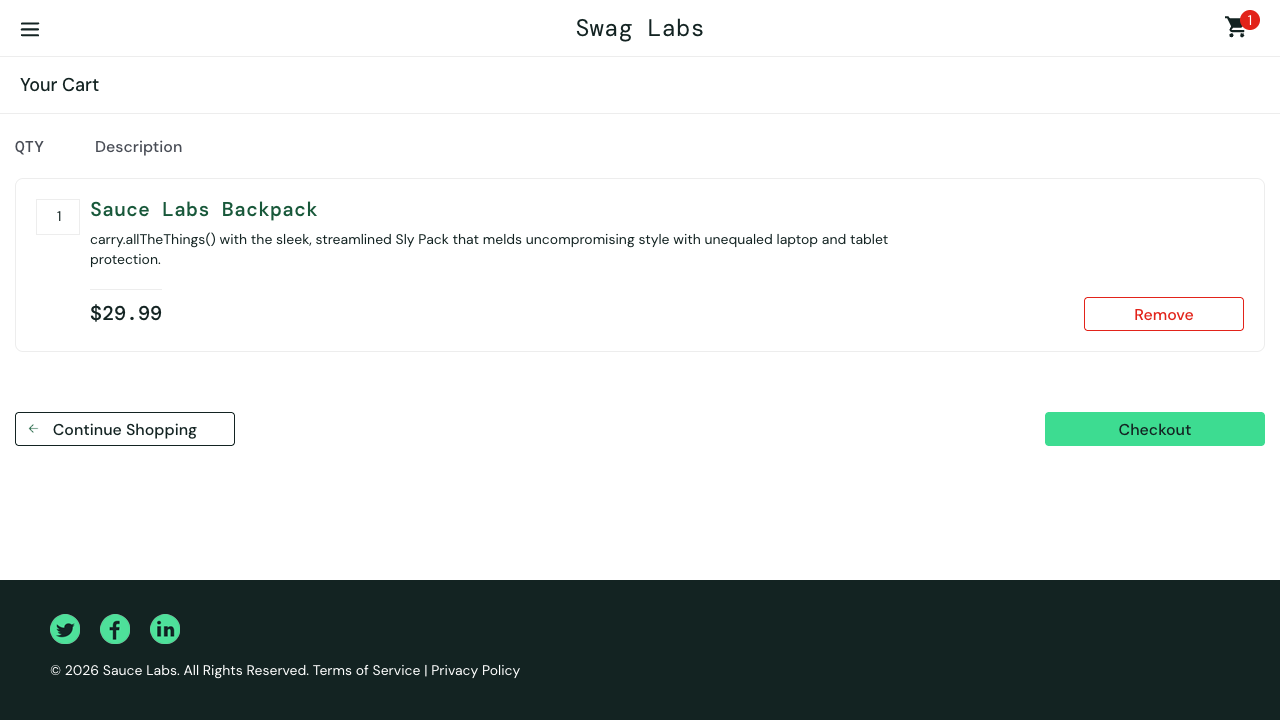
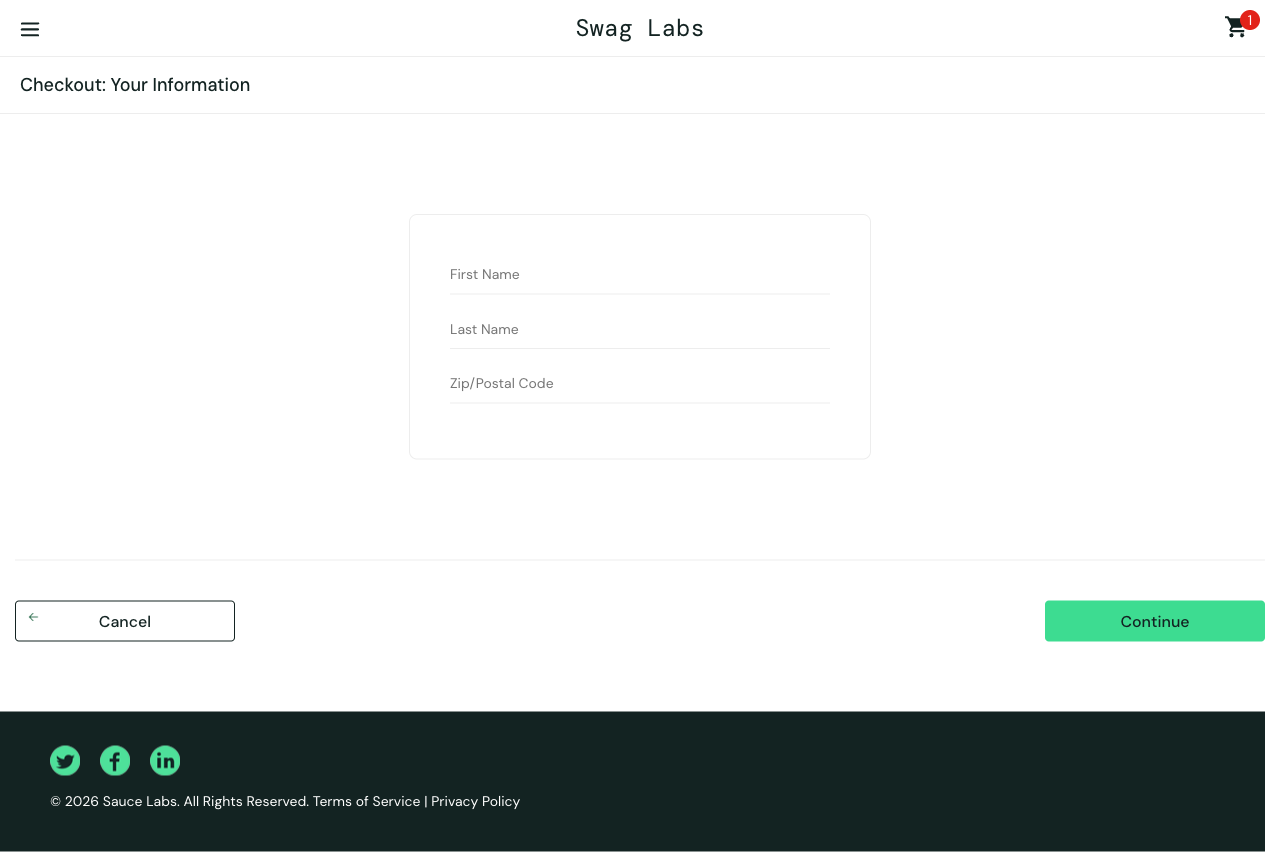

In [4]:
#Cell 4: HTML Preview
def display_report(html_path, title):
    print(f"{title}")
    with open(html_path, "r", encoding="utf-8") as file:
        html_content = file.read()
    display(HTML(html_content))

#Standard user report
display_report(result_standard["html_path"], "standard_user report:")

problem_user report:


Target Application,https://www.saucedemo.com
User Role Tested,problem_user
Pages Analysed,4
Total Issues,"15 (0 critical, 4 major, 11 minor)"
Run ID,2

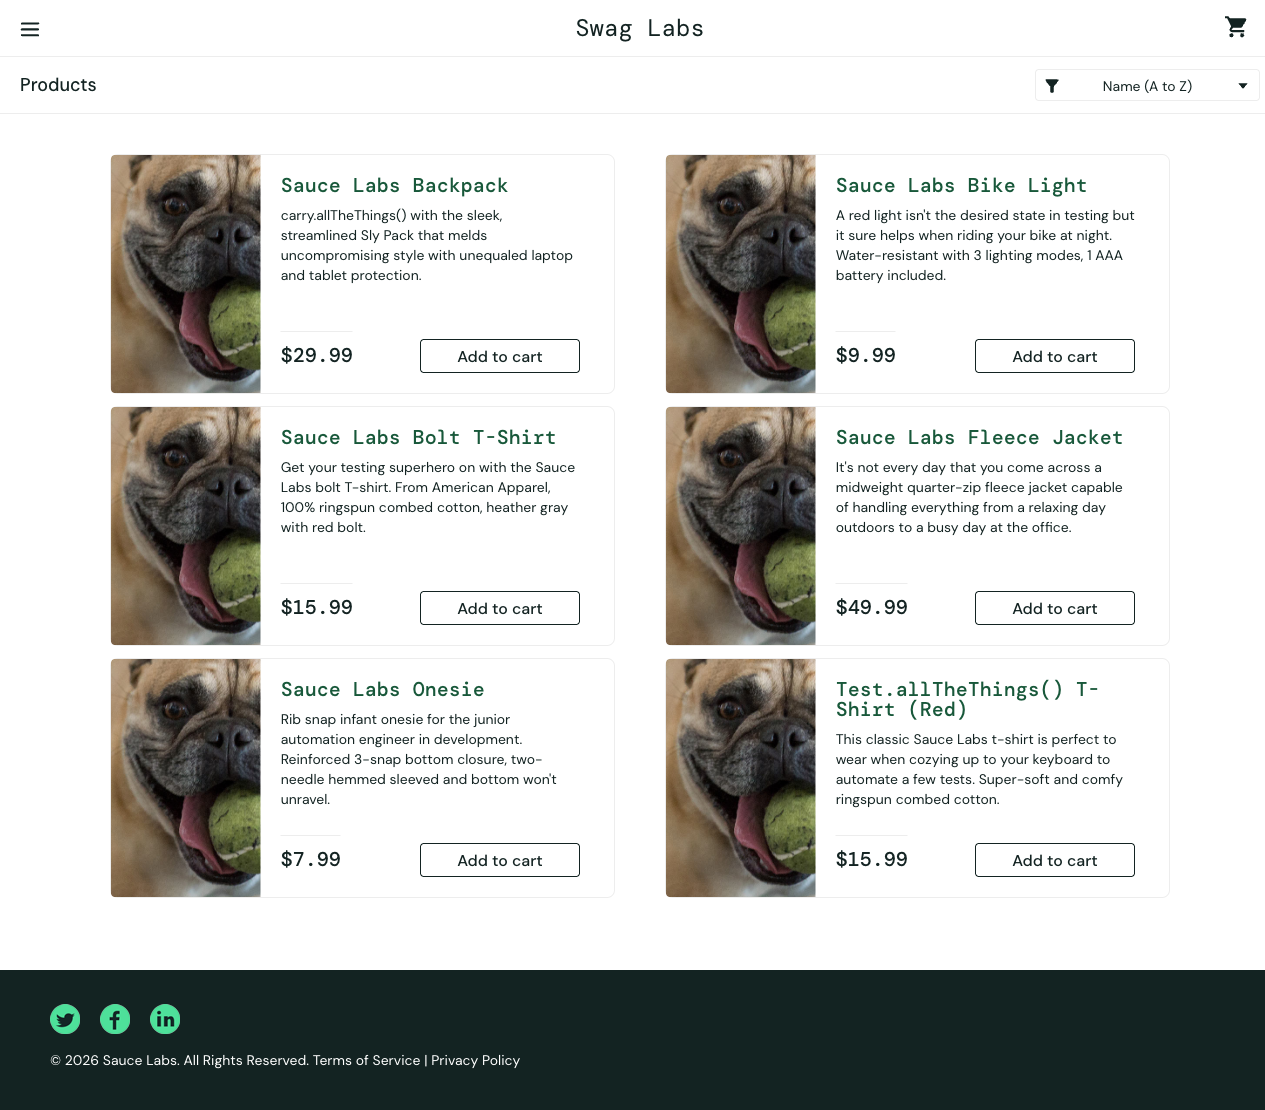
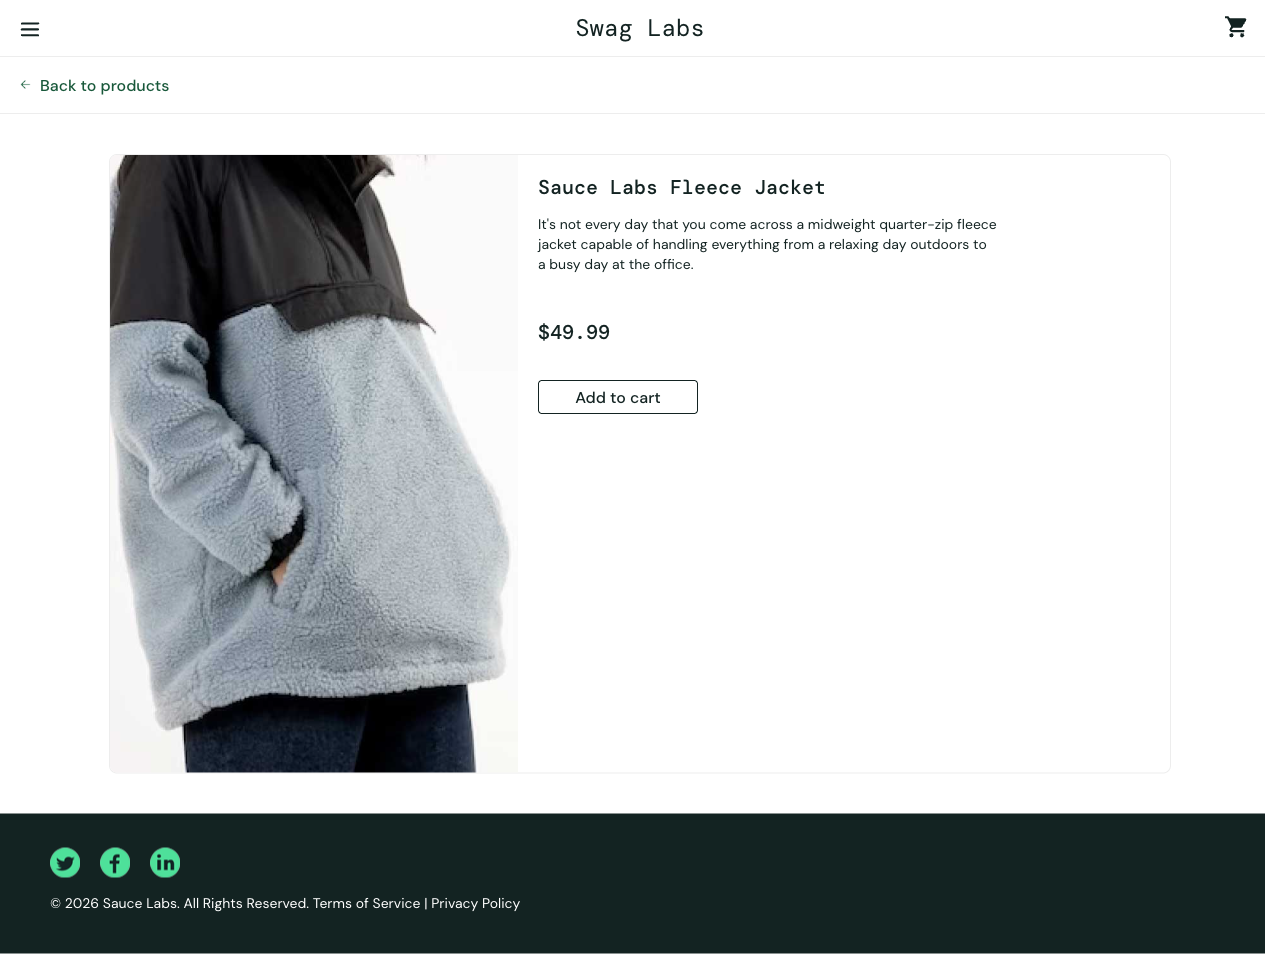
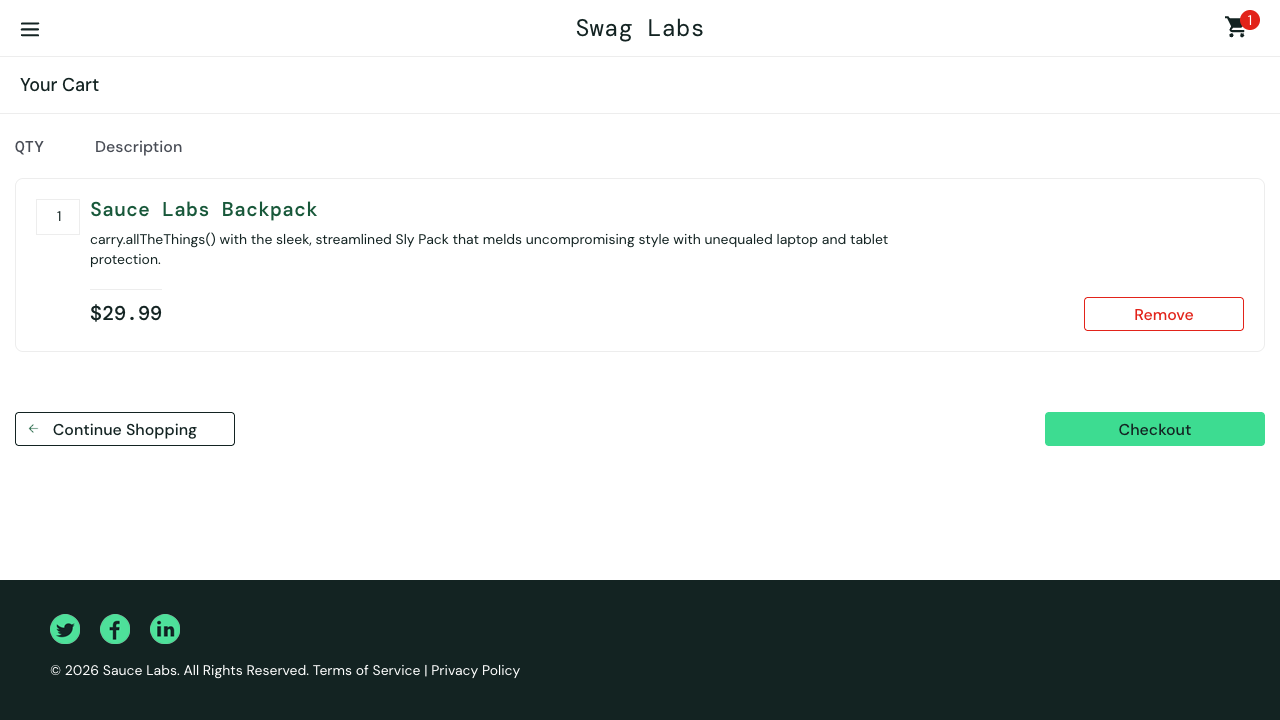
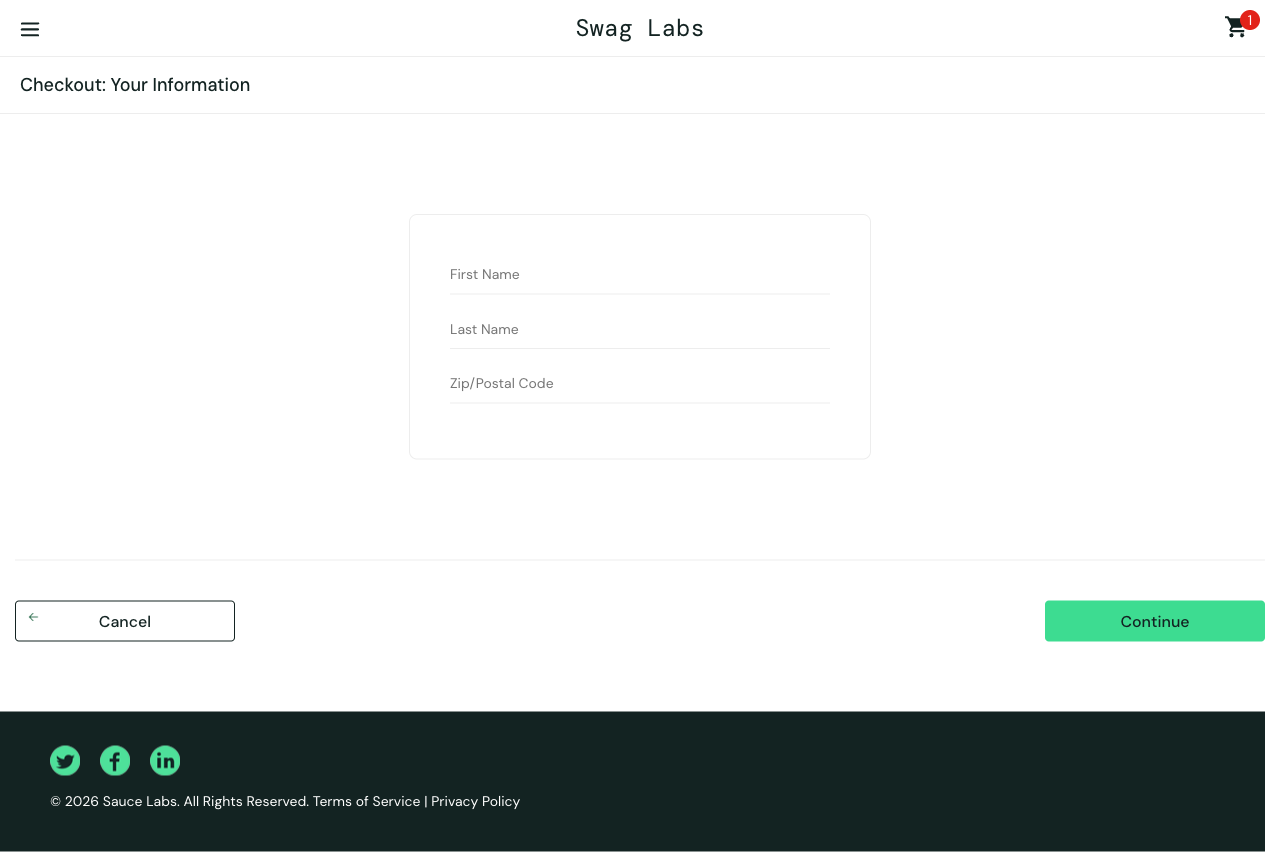
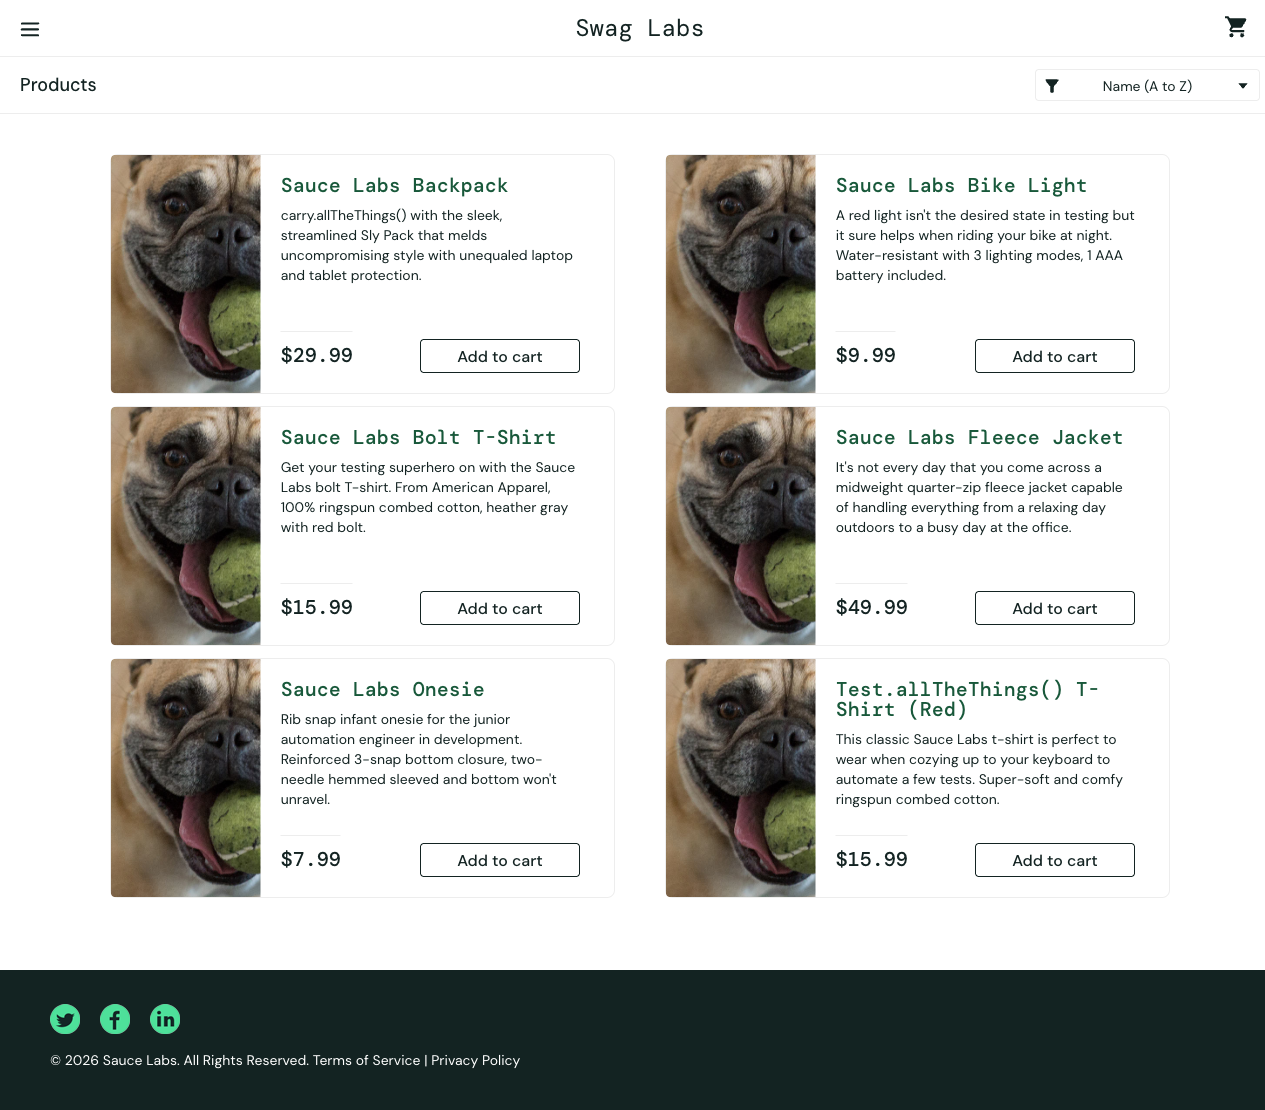
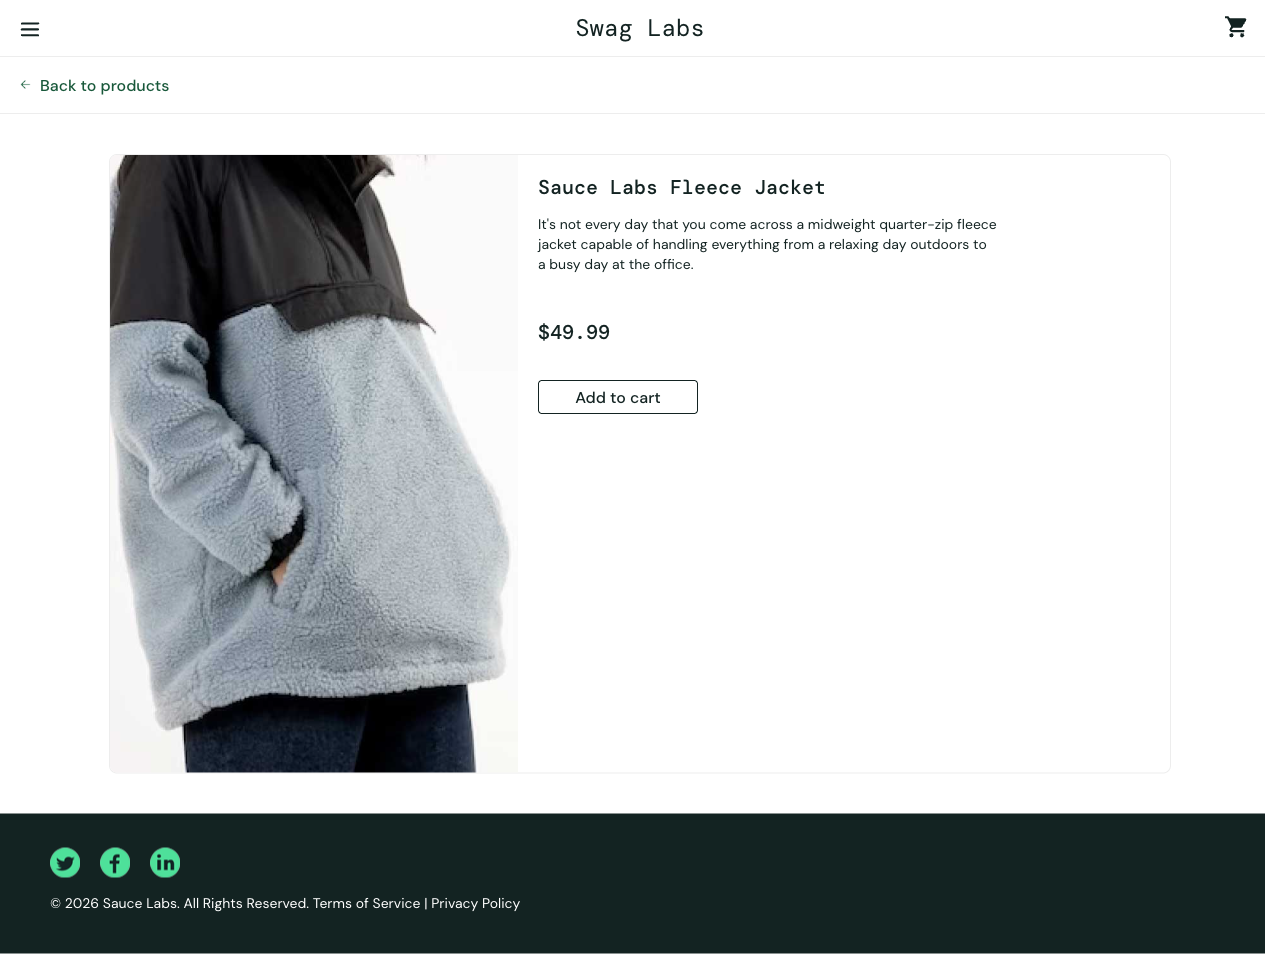
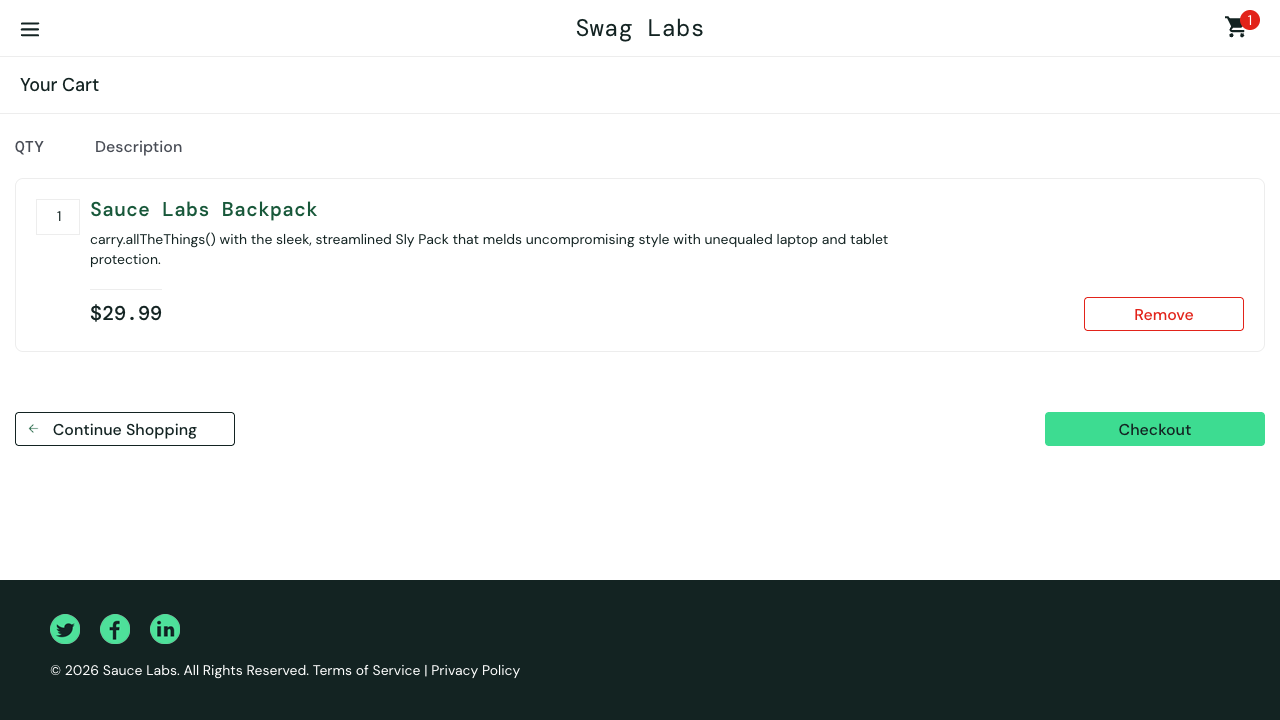
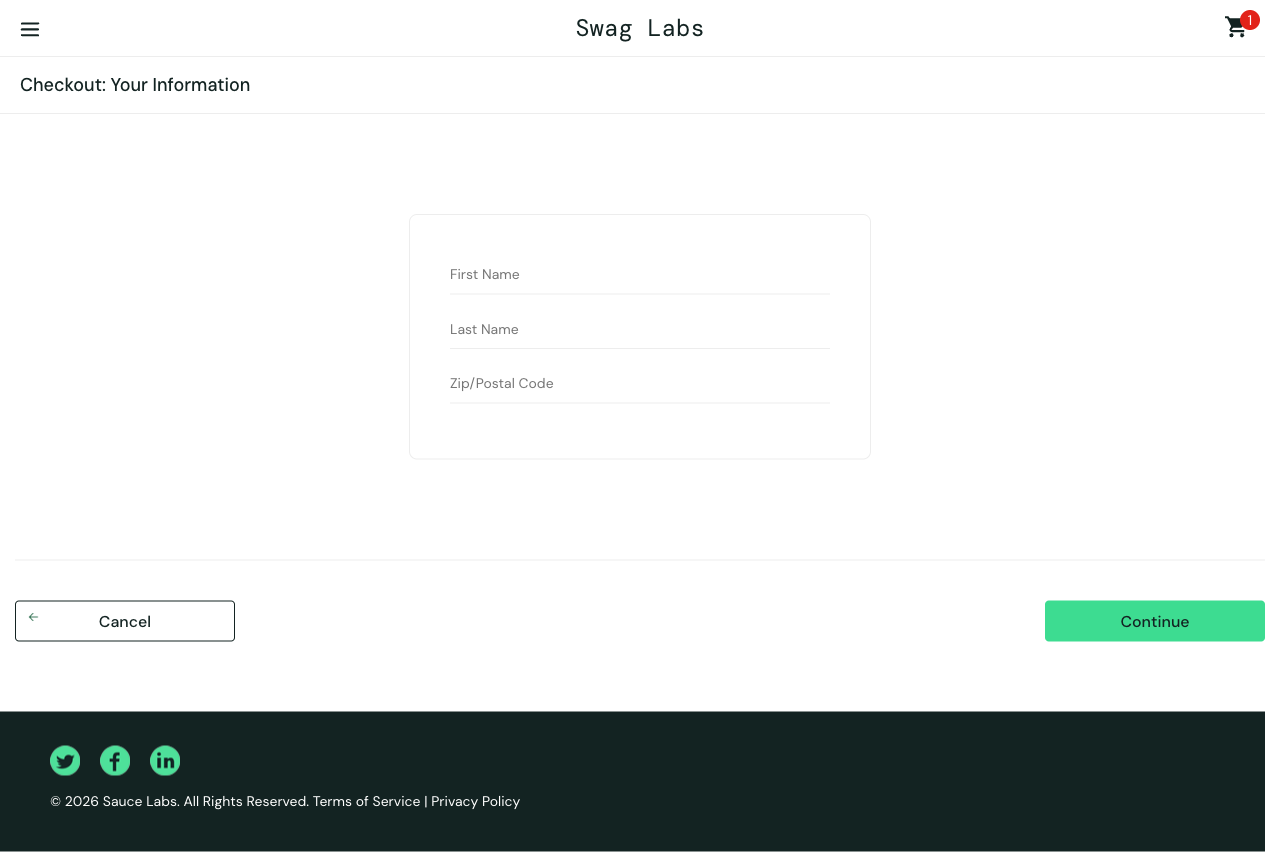

In [5]:
#Cell 5: HTML Preview - problem_user report
display_report(result_problem["html_path"], "problem_user report:")

In [6]:
#Cell 6: Ground Truth Evaluation
#Pull problem_user findings from the database (run_id = 2)
conn = get_conn()
cursor = conn.cursor()
cursor.execute("""
    SELECT description, issue_type, severity, page_url 
    FROM findings 
    WHERE run_id = 2
""")
problem_findings_db = cursor.fetchall()
conn.close()

#Ground truth bugs for problem_user
#Source: github.com/lakshithadil/Test-Automation-for-Swag-Labs
#Bugs verified through automated Cucumber/Selenium test execution
ground_truth = [
    {
        "id": "BG_04",
        "module": "Inventory",
        "title": "Product 1 description is wrong for problem_user",
        "visually_detectable": True,
        "keywords": ["wrong description", "incorrect description", "product description", "carry.allthethings", "description is wrong"]
    },
    {
        "id": "BG_05",
        "module": "Inventory",
        "title": "Product 6 name is wrong for problem_user",
        "visually_detectable": True,
        "keywords": ["wrong name", "incorrect name", "product name", "test.allthethings", "name is wrong"]
    },

    {
        "id": "BG_08",
        "module": "Inventory",
        "title": "Incorrectly sorted Z to A for problem_user",
        "visually_detectable": False,
        "keywords": ["sort z to a", "sorting z to a", "incorrect sort", "sorting incorrect"]
    },
    {
        "id": "BG_09",
        "module": "Inventory",
        "title": "Sort option button not working for problem_user",
        "visually_detectable": False,
        "keywords": ["sort option not working", "sort button broken", "sorting button", "sort not working"]
    },
    {
        "id": "BG_10",
        "module": "Inventory",
        "title": "Incorrectly sorted price low to high for problem_user",
        "visually_detectable": False,
        "keywords": ["price low to high", "price sorting incorrect", "price sort broken"]
    },
    {
        "id": "BG_11",
        "module": "Inventory",
        "title": "Incorrectly sorted price high to low for problem_user",
        "visually_detectable": False,
        "keywords": ["price high to low", "price sorting incorrect", "price sort broken"]
    },
    {
        "id": "BG_12",
        "module": "Inventory",
        "title": "Incorrect product images for problem_user",
        "visually_detectable": True,
        "keywords": ["identical image", "same image", "wrong image", "incorrect image", "broken image", "dog"]
    },
    {
        "id": "BG_13",
        "module": "Inventory",
        "title": "Add to cart buttons 3, 4 and 6 not working",
        "visually_detectable": False,
        "keywords": ["add to cart button does not work", "button non-functional", "button not responding", "add to cart broken"]
    },
    {
        "id": "BG_14",
        "module": "Inventory",
        "title": "Remove buttons not displayed for problem_user",
        "visually_detectable": False,
        "keywords": ["remove button not displayed", "remove button missing", "remove button broken"]
    },
    {
        "id": "BG_15",
        "module": "Inventory",
        "title": "Incorrect navigation in full product view",
        "visually_detectable": False,
        "keywords": ["incorrect navigation", "navigation broken", "product navigation", "full view navigation"]
    },
    {
        "id": "BG_16",
        "module": "Cart",
        "title": "Fail to add to cart products 3, 4 and 6 for problem_user",
        "visually_detectable": False,
        "keywords": ["fail to add", "cannot add", "add to cart fails", "product not added"]
    },
    {
        "id": "BG_17",
        "module": "Cart",
        "title": "Fail to remove from cart products 3, 4 and 6 for problem_user",
        "visually_detectable": False,
        "keywords": ["fail to remove", "cannot remove", "remove fails", "product not removed"]
    }
]

#Separate into visually detectable vs interaction dependent
visual_bugs = [gt for gt in ground_truth if gt["visually_detectable"]]
interaction_bugs = [gt for gt in ground_truth if not gt["visually_detectable"]]

#Match findings against ground truth using keyword search
print("GROUND TRUTH EVALUATION — problem_user")
print("Source: github.com/lakshithadil/Test-Automation-for-Swag-Labs")
print("Verified via automated Cucumber/Selenium test execution")
print("="*80)
print(f"{'ID':<10} {'Module':<12} {'Title':<45} {'Detectable?':<25} {'Found?'}")
print("-"*80)

detected = 0
visual_detected = 0

for gt in ground_truth:
    matched = False
    for finding in problem_findings_db:
        description = finding[0].lower()
        if any(keyword in description for keyword in gt["keywords"]):
            matched = True
            break

    status = "YES" if matched else "NO"
    detectable = "Visual" if gt["visually_detectable"] else "Requires interaction"

    if matched:
        detected += 1
        if gt["visually_detectable"]:
            visual_detected += 1

    print(f"{gt['id']:<10} {gt['module']:<12} {gt['title'][:44]:<45} {detectable:<25} {status}")

print("-"*80)
print(f"\nTotal known bugs:                    {len(ground_truth)}")
print(f"Visually detectable bugs:            {len(visual_bugs)}")
print(f"Interaction-dependent bugs:          {len(interaction_bugs)}")
print(f"\nOverall bugs detected:               {detected}/{len(ground_truth)} ({detected/len(ground_truth)*100:.0f}% recall)")
print(f"Visually detectable bugs detected:   {visual_detected}/{len(visual_bugs)} ({visual_detected/len(visual_bugs)*100:.0f}% recall)")
print(f"Interaction-dependent bugs detected: {detected - visual_detected}/{len(interaction_bugs)} (0% recall — expected)")
print(f"\nTotal findings generated:            {len(problem_findings_db)}")
print(f"Confirmed true positives:            {detected}")
print(f"Precision (lower bound):             {detected/len(problem_findings_db)*100:.0f}%")

GROUND TRUTH EVALUATION — problem_user
Source: github.com/lakshithadil/Test-Automation-for-Swag-Labs
Verified via automated Cucumber/Selenium test execution
ID         Module       Title                                         Detectable?               Found?
--------------------------------------------------------------------------------
BG_04      Inventory    Product 1 description is wrong for problem_u  Visual                    YES
BG_05      Inventory    Product 6 name is wrong for problem_user      Visual                    YES
BG_08      Inventory    Incorrectly sorted Z to A for problem_user    Requires interaction      NO
BG_09      Inventory    Sort option button not working for problem_u  Requires interaction      NO
BG_10      Inventory    Incorrectly sorted price low to high for pro  Requires interaction      NO
BG_11      Inventory    Incorrectly sorted price high to low for pro  Requires interaction      NO
BG_12      Inventory    Incorrect product images for problem_us

In [7]:
# Cell 7: Comparison Analysis
print("COMPARISON ANALYSIS — standard_user vs problem_user")
print("="*60)
print(f"{'Metric':<35} {'standard_user':>12} {'problem_user':>12}")
print("-"*60)
print(f"{'Total findings':<35} {len(standard_findings):>12} {len(problem_findings):>12}")
print(f"{'Critical':<35} {count_severity(standard_findings, 'critical'):>12} {count_severity(problem_findings, 'critical'):>12}")
print(f"{'Major':<35} {count_severity(standard_findings, 'major'):>12} {count_severity(problem_findings, 'major'):>12}")
print(f"{'Minor':<35} {count_severity(standard_findings, 'minor'):>12} {count_severity(problem_findings, 'minor'):>12}")
print("-"*60)

diff_total = len(problem_findings) - len(standard_findings)
diff_major = count_severity(problem_findings, "major") - count_severity(standard_findings, "major")

print(f"\nTotal difference: {abs(diff_total)} {'more' if diff_total > 0 else 'fewer' if diff_total < 0 else 'equal'} findings in problem_user")
print(f"Major difference: {abs(diff_major)} {'more' if diff_major > 0 else 'fewer' if diff_major < 0 else 'equal'} major findings in problem_user")

print("""
Key Observations:
      
1. The Vision Agent correctly detected BG_12 (incorrect product images)
   and BG_04/BG_05 (wrong product descriptions and names) in problem_user
   but not in standard_user, confirming correct baseline differentiation
   for visually detectable defects.

2. Total finding counts were equal across both users (15 vs 15),
   reflecting that both share genuine UX issues visible in screenshots
   such as missing field labels, low contrast, and unlabelled footer icons.
   This reduces the contrast between runs and is a known limitation
   of vision-only analysis against a shared UI baseline.

3. problem_user produced more major findings than standard_user,
   consistent with the known presence of additional visual defects
   such as incorrect product images and wrong product text.

4. 9 of 12 ground truth bugs are interaction-dependent and were not
   detected by either run, confirming the fundamental limitation of
   vision-only analysis and directly motivating the Reason Agent
   in the full implementation.

5. Overall recall was 25% (3/12) and vision-scoped recall was 100%
   (3/3), meaning the prototype detected every bug it was architecturally
   capable of detecting given its current design.
""")

COMPARISON ANALYSIS — standard_user vs problem_user
Metric                              standard_user problem_user
------------------------------------------------------------
Total findings                                13           15
Critical                                       0            0
Major                                          1            4
Minor                                         12           11
------------------------------------------------------------

Total difference: 2 more findings in problem_user
Major difference: 3 more major findings in problem_user

Key Observations:
      
1. The Vision Agent correctly detected BG_12 (incorrect product images)
   and BG_04/BG_05 (wrong product descriptions and names) in problem_user
   but not in standard_user, confirming correct baseline differentiation
   for visually detectable defects.

2. Total finding counts were equal across both users (15 vs 15),
   reflecting that both share genuine UX issues visible in sc

## Conclusions & Limitations

### What Worked
- The end-to-end pipeline executed successfully across two runs on a live web application
- The Vision Agent correctly detected all three visually observable ground truth bugs
  (BG_04, BG_05, BG_12) in problem_user but not in standard_user, confirming correct
  baseline differentiation
- Vision-scoped recall was 100% — every bug detectable from screenshots alone was found
- The HTML report with embedded screenshots and recommended fixes provides actionable output
- SQLite run tracking enables reproducibility across pipeline runs
- The modular architecture (Crawl → Vision → Report → HTML Renderer) maps directly
  to the proposed system design and was validated end-to-end

### Limitations
- Vision-only analysis cannot detect interaction-dependent defects — 9 of 12 ground
  truth bugs required active browser interaction to trigger (button clicks, sort triggers,
  form submissions), placing them outside the detection scope of this prototype
- LLM severity assignment is non-deterministic and inconsistent across runs,
  motivating the proposed DistilBERT classifier in the full implementation
- Hardcoded crawl path limits generalisability beyond SauceDemo — the full
  implementation will replace this with an LLM-guided autonomous crawler
- Hallucinated findings were observed (e.g. social media icons flagged as non-clickable),
  reducing precision to 20% against the ground truth set
- No Reason Agent — DOM-based functional analysis is absent from this prototype,
  which accounts for the 0% recall on interaction-dependent bugs

### Planned Improvements for Full Implementation
- Add Reason Agent for DOM-based functional analysis to address the 9
  interaction-dependent bugs (BG_08 through BG_17)
- Replace inline LLM severity labelling with a dedicated DistilBERT classifier
  for consistent, reproducible severity labels
- Implement LLM-guided autonomous crawler following Naqvi et al. (2026)
  to generalise beyond hardcoded navigation paths
- Refine Vision Agent prompt engineering to reduce hallucinated findings
  and improve precision
- Add FastAPI backend and React dashboard as described in the design chapter
- Expand evaluation using ROUGE-1 and SBERT against reference bug reports
  following the AgentReport methodology (Choi & Yang, 2025)